# Pressupostos e diagnóstico

**Tema:** Aprendizado Supervisionado › Regressão Linear

Este notebook constrói, deliberadamente, um caso de cada violação dos
pressupostos LINE — não-linearidade, heterocedasticidade, não-normalidade e
um ponto de alta influência — e mostra o gráfico de diagnóstico que
denuncia cada uma.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Um ajuste "saudável", para servir de referência

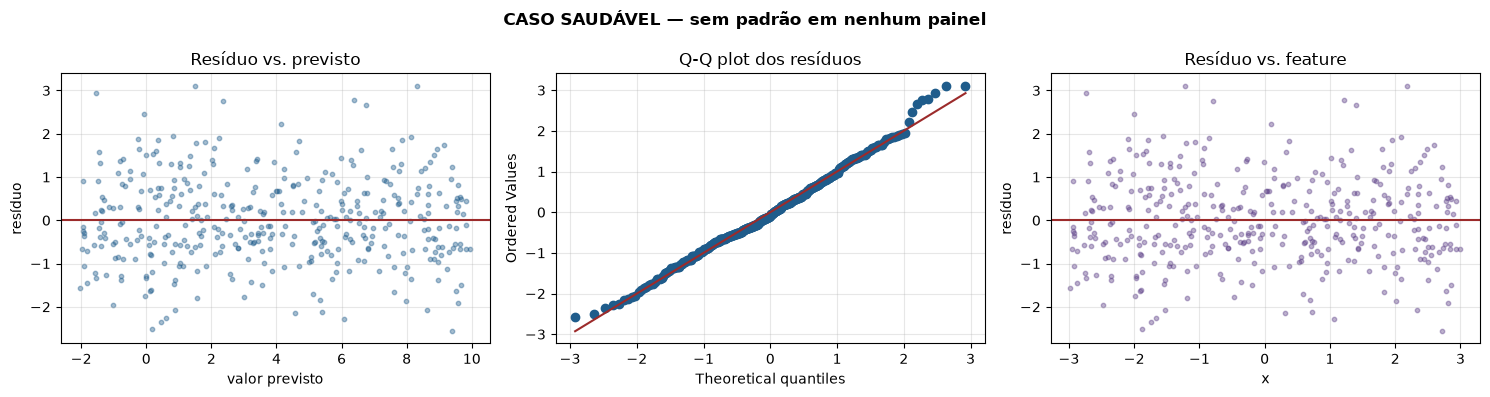

In [2]:
n = 400
x = rng.uniform(-3, 3, n)
y_saudavel = 4 + 2 * x + rng.normal(0, 1, n)

modelo_saudavel = LinearRegression().fit(x.reshape(-1, 1), y_saudavel)
pred_saudavel = modelo_saudavel.predict(x.reshape(-1, 1))
res_saudavel = y_saudavel - pred_saudavel


def paineis_diagnostico(x, y, y_hat, residuos, titulo):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].scatter(y_hat, residuos, s=10, alpha=0.4, color=AZUL)
    axes[0].axhline(0, color=VERMELHO, lw=1.5)
    axes[0].set_xlabel("valor previsto"); axes[0].set_ylabel("resíduo")
    axes[0].set_title("Resíduo vs. previsto")

    stats.probplot(residuos, dist="norm", plot=axes[1])
    axes[1].get_lines()[0].set_color(AZUL)
    axes[1].get_lines()[1].set_color(VERMELHO)
    axes[1].set_title("Q-Q plot dos resíduos")

    axes[2].scatter(x, residuos, s=10, alpha=0.4, color=ROXO)
    axes[2].axhline(0, color=VERMELHO, lw=1.5)
    axes[2].set_xlabel("x"); axes[2].set_ylabel("resíduo")
    axes[2].set_title("Resíduo vs. feature")

    fig.suptitle(titulo, fontweight="bold")
    plt.tight_layout(); plt.show()


paineis_diagnostico(x, y_saudavel, pred_saudavel, res_saudavel,
                    "CASO SAUDÁVEL — sem padrão em nenhum painel")

**O que "saudável" parece:** nuvem de pontos sem forma nos dois primeiros
painéis, pontos alinhados à reta no Q-Q plot. Guarde esta imagem como
referência para os casos problemáticos a seguir.

## 2. Não-linearidade: ajustando uma reta a uma curva

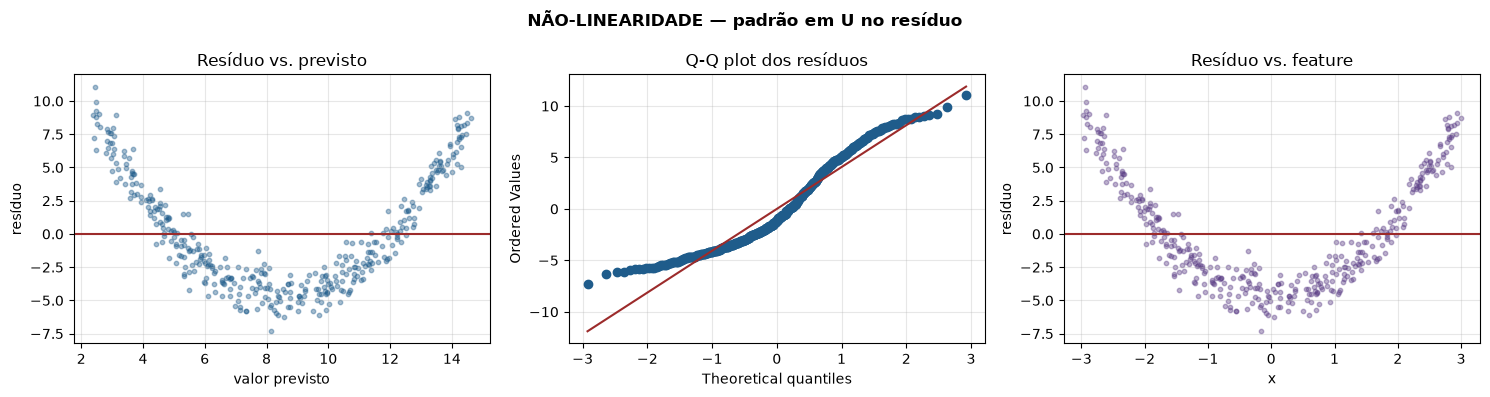

In [3]:
y_nao_linear = 4 + 2 * x + 1.5 * x**2 + rng.normal(0, 1, n)
modelo_nl = LinearRegression().fit(x.reshape(-1, 1), y_nao_linear)
pred_nl = modelo_nl.predict(x.reshape(-1, 1))
res_nl = y_nao_linear - pred_nl

paineis_diagnostico(x, y_nao_linear, pred_nl, res_nl,
                    "NÃO-LINEARIDADE — padrão em U no resíduo")

**O sinal:** um padrão curvo e sistemático no painel resíduo-vs-previsto (e
no resíduo-vs-feature) — o modelo erra para cima nos extremos e para baixo
no meio (ou vice-versa), porque uma reta não pode acompanhar uma parábola.
**A correção:** adicionar um termo $x^2$ (ainda regressão *linear nos
parâmetros*, como o `teoria.pdf` explica) ou transformar a feature.

## 3. Heterocedasticidade: variância que cresce com o previsto

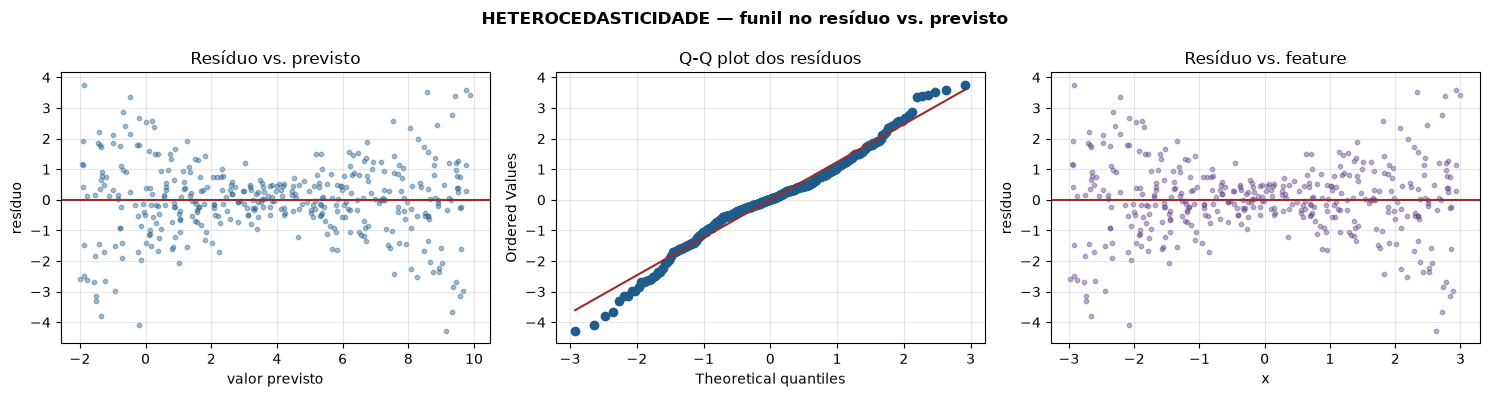

In [4]:
y_heterocedastico = 4 + 2 * x + rng.normal(0, 0.3 + 0.5 * np.abs(x), n)
modelo_het = LinearRegression().fit(x.reshape(-1, 1), y_heterocedastico)
pred_het = modelo_het.predict(x.reshape(-1, 1))
res_het = y_heterocedastico - pred_het

paineis_diagnostico(x, y_heterocedastico, pred_het, res_het,
                    "HETEROCEDASTICIDADE — funil no resíduo vs. previsto")

**O sinal:** o "funil" no primeiro painel — a dispersão dos resíduos cresce
conforme o valor previsto se afasta do centro. **A consequência:** os
coeficientes continuam não-viesados, mas os erros-padrão calculados da
forma clássica ficam errados — intervalos de confiança e p-valores não são
confiáveis. **A correção mais simples:** transformar o alvo (log, se
positivo) ou usar erros-padrão robustos a heterocedasticidade.

## 4. Não-normalidade dos erros

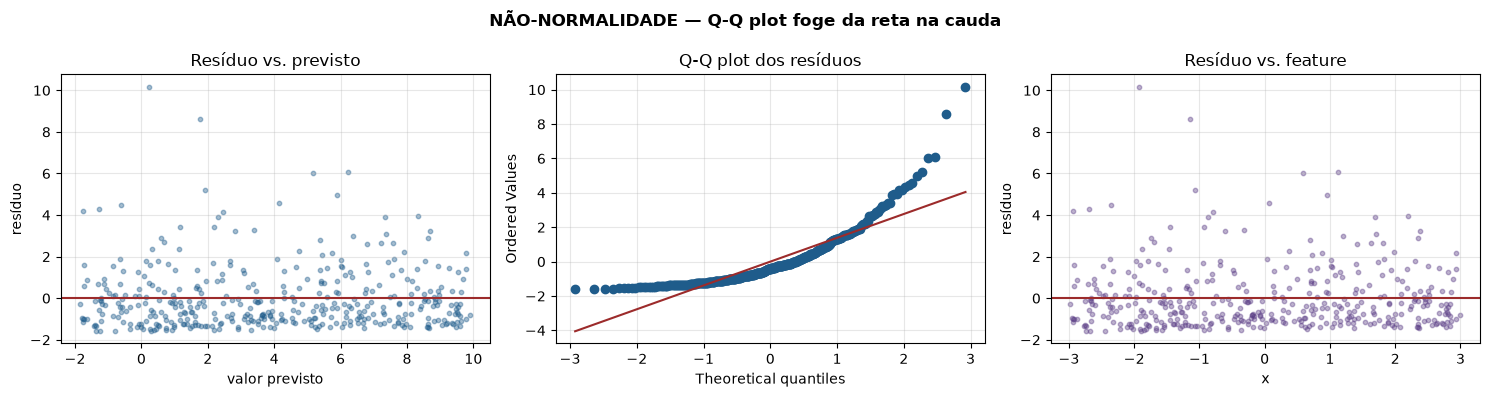

In [5]:
y_nao_normal = 4 + 2 * x + rng.exponential(1.5, n) - 1.5  # erro assimétrico
modelo_nn = LinearRegression().fit(x.reshape(-1, 1), y_nao_normal)
pred_nn = modelo_nn.predict(x.reshape(-1, 1))
res_nn = y_nao_normal - pred_nn

paineis_diagnostico(x, y_nao_normal, pred_nn, res_nn,
                    "NÃO-NORMALIDADE — Q-Q plot foge da reta na cauda")

**O sinal:** os pontos do Q-Q plot se afastam da reta, tipicamente numa
cauda. **A gravidade:** com $n$ grande, o Teorema Central do Limite (tema 1)
ainda garante que a distribuição amostral de $\hat\beta$ seja
aproximadamente normal — não-normalidade dos erros individuais preocupa
mais em amostras pequenas.

## 5. Pontos de alta influência: distância de Cook

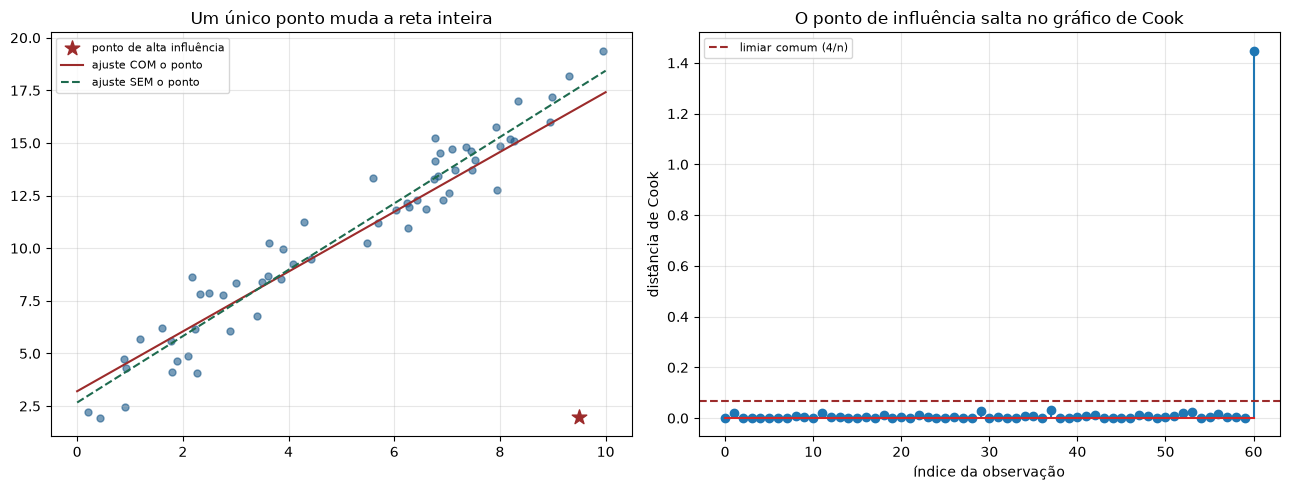

coeficiente angular COM o ponto: 1.421
coeficiente angular SEM o ponto: 1.577

distância de Cook do ponto suspeito: 1.4480
limiar de referência (4/n): 0.0656


In [6]:
x_influencia = rng.uniform(0, 10, 60)
y_influencia = 3 + 1.5 * x_influencia + rng.normal(0, 1, 60)
# um ponto extremo em x E fora do padrão em y -- alta ALAVANCAGEM e alto resíduo
x_influencia = np.append(x_influencia, 9.5)
y_influencia = np.append(y_influencia, 2.0)  # deveria ser ~17 nesse x

X_influencia = np.column_stack([np.ones(len(x_influencia)), x_influencia])
beta_influencia = np.linalg.lstsq(X_influencia, y_influencia, rcond=None)[0]
H = X_influencia @ np.linalg.inv(X_influencia.T @ X_influencia) @ X_influencia.T
alavancagem = np.diag(H)
residuos_influencia = y_influencia - X_influencia @ beta_influencia
p_mais_1 = X_influencia.shape[1]
sigma2 = np.sum(residuos_influencia**2) / (len(y_influencia) - p_mais_1)
residuo_padronizado = residuos_influencia / np.sqrt(sigma2 * (1 - alavancagem))
distancia_cook = (residuo_padronizado**2 / p_mais_1) * (alavancagem / (1 - alavancagem))

# ajuste SEM o ponto suspeito, para comparar
sem_outlier = slice(0, -1)
beta_sem = np.linalg.lstsq(X_influencia[sem_outlier], y_influencia[sem_outlier], rcond=None)[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(x_influencia[:-1], y_influencia[:-1], s=25, alpha=0.6, color=AZUL)
axes[0].scatter([x_influencia[-1]], [y_influencia[-1]], s=120, color=VERMELHO,
               marker="*", label="ponto de alta influência", zorder=5)
xs = np.linspace(0, 10, 50)
axes[0].plot(xs, beta_influencia[0] + beta_influencia[1] * xs, color=VERMELHO,
            label="ajuste COM o ponto")
axes[0].plot(xs, beta_sem[0] + beta_sem[1] * xs, color=VERDE, ls="--",
            label="ajuste SEM o ponto")
axes[0].legend(fontsize=8); axes[0].set_title("Um único ponto muda a reta inteira")

axes[1].stem(distancia_cook)
axes[1].axhline(4 / len(y_influencia), color=VERMELHO, ls="--",
                label="limiar comum (4/n)")
axes[1].set_xlabel("índice da observação"); axes[1].set_ylabel("distância de Cook")
axes[1].set_title("O ponto de influência salta no gráfico de Cook")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"coeficiente angular COM o ponto: {beta_influencia[1]:.3f}")
print(f"coeficiente angular SEM o ponto: {beta_sem[1]:.3f}")
print(f"\ndistância de Cook do ponto suspeito: {distancia_cook[-1]:.4f}")
print(f"limiar de referência (4/n): {4/len(y_influencia):.4f}")

**O ponto:** um único ponto com alta alavancagem (valor extremo em $x$) e
resíduo alto muda visivelmente a inclinação da reta inteira — de ~1,5 para
um valor bem diferente. A distância de Cook aponta exatamente esse ponto,
muito acima do limiar de referência. **A decisão** (tema 3, módulo 2) não é
automática: investigue se é erro de coleta ou um caso real antes de decidir
o que fazer.

## O que levar deste notebook

- Cada painel de diagnóstico tem um padrão "saudável" (sem forma) e
  padrões específicos para cada violação — memorize a assinatura visual de
  cada um.
- Não-linearidade pede transformação de feature ou termos polinomiais;
  heterocedasticidade pede transformação do alvo ou erros-padrão robustos.
- A distância de Cook quantifica o quanto um único ponto está distorcendo o
  ajuste inteiro — é o ponto de partida da investigação, não a decisão
  final.

→ Próximo: **Caso real de precificação**, aplicando tudo isso a um
problema completo, com preparação de dados incluída.